# Statistical Analysis - Air Quality Dataset

Basic statistical analysis and validation of the cleaned air quality data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")    
plt.rcParams['figure.figsize'] = (12, 6)
data = pd.read_csv('../Data/processed/clean_data.csv')

## Basic Statistics

In [3]:
print("Overall Dataset Statistics:")
print(f"Total Records: {len(data):,}")
print(f"Date Range: {data['date'].min()} to {data['date'].max()}")
print(f"Total States: {data['state'].nunique()}")
print(f"Total Areas: {data['area'].nunique()}")


Overall Dataset Statistics:
Total Records: 425,138
Date Range: 2015-05-15 to 2025-06-19
Total States: 32
Total Areas: 295


## Correlation Analysis

In [4]:
numeric_cols = ['aqi_value', 'number_of_monitoring_stations', 'year', 'month', 'day', 'quality_level']
correlation = data[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation)

print("Key Correlations with AQI:")
aqi_corr = correlation['aqi_value'].sort_values(ascending=False)
print(aqi_corr)

Correlation Matrix:
                               aqi_value  number_of_monitoring_stations  \
aqi_value                       1.000000                       0.075773   
number_of_monitoring_stations   0.075773                       1.000000   
year                           -0.162854                       0.026331   
month                           0.005860                       0.000827   
day                             0.001734                       0.000320   
quality_level                   0.934951                       0.074714   

                                   year     month       day  quality_level  
aqi_value                     -0.162854  0.005860  0.001734       0.934951  
number_of_monitoring_stations  0.026331  0.000827  0.000320       0.074714  
year                           1.000000 -0.151330 -0.014780      -0.146285  
month                         -0.151330  1.000000  0.010829      -0.027417  
day                           -0.014780  0.010829  1.000000       0.0

## Visualization - Correlation Heatmap

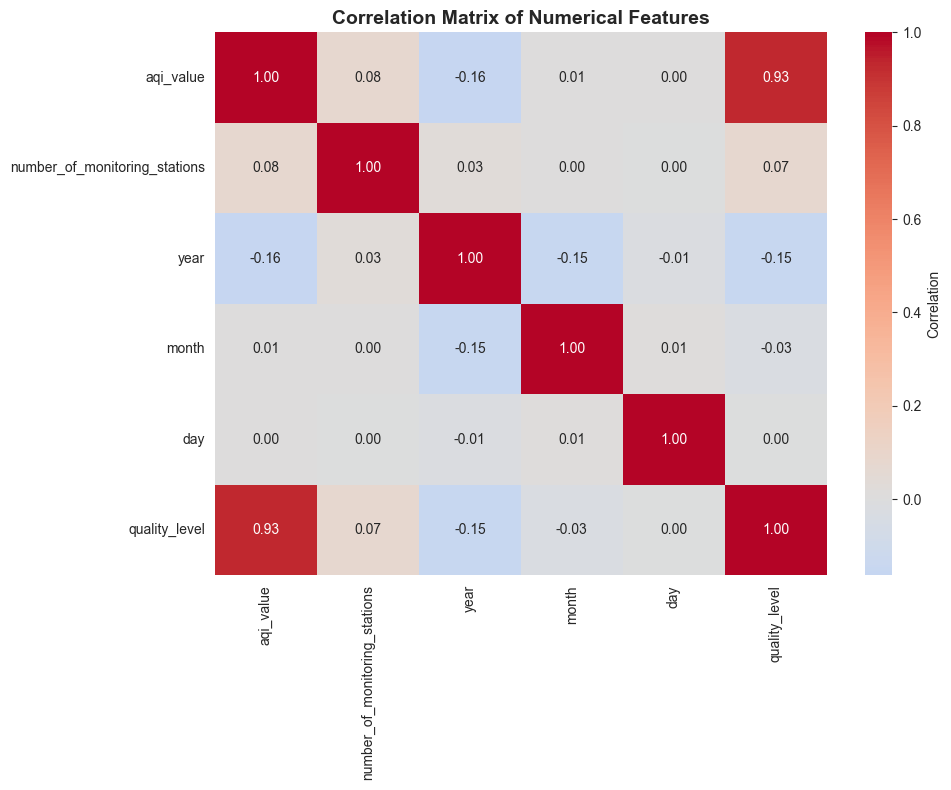

Interpretation:
Values close to 1: Strong +ve relationship
Values close to -1: Strong _ve relationship
Values close to 0: No relationship


In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("Values close to 1: Strong +ve relationship")
print("Values close to -1: Strong _ve relationship")
print("Values close to 0: No relationship")

## Compare AQI by Quality Status

In [5]:
print("<<--- AQI Statistics by Quality Status --->>")
print(data.groupby('air_quality_status')['aqi_value'].describe())

print("<<-- Average Values by Quality Status -->>")
stats_by_status = data.groupby('air_quality_status')[['aqi_value', 'number_of_monitoring_stations']].agg(['mean', 'count'])
print(stats_by_status)

<<--- AQI Statistics by Quality Status --->>
                       count        mean        std    min    25%    50%  \
air_quality_status                                                         
Good                 69750.0   38.529677   8.674596    3.0   33.0   40.0   
Moderate            138489.0  139.205569  27.882115   71.0  115.0  134.0   
Poor                 43784.0  243.288690  28.321008  200.0  218.0  240.0   
Satisfactory        155167.0   74.118066  14.316014   25.0   62.0   73.0   
Severe                2564.0  430.609594  23.894245  398.0  411.0  425.0   
Very Poor            15384.0  339.402626  27.212799  300.0  316.0  335.0   

                      75%    max  
air_quality_status                
Good                 46.0   50.0  
Moderate            161.0  200.0  
Poor                266.0  300.0  
Satisfactory         86.0  111.0  
Severe              446.0  500.0  
Very Poor           360.0  400.0  
<<-- Average Values by Quality Status -->>
                     aq

## AQI Distribution by Status

C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_20392\342280862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='air_quality_status', y='aqi_value', data=data_sorted, ax=axes[0], palette='Set2')


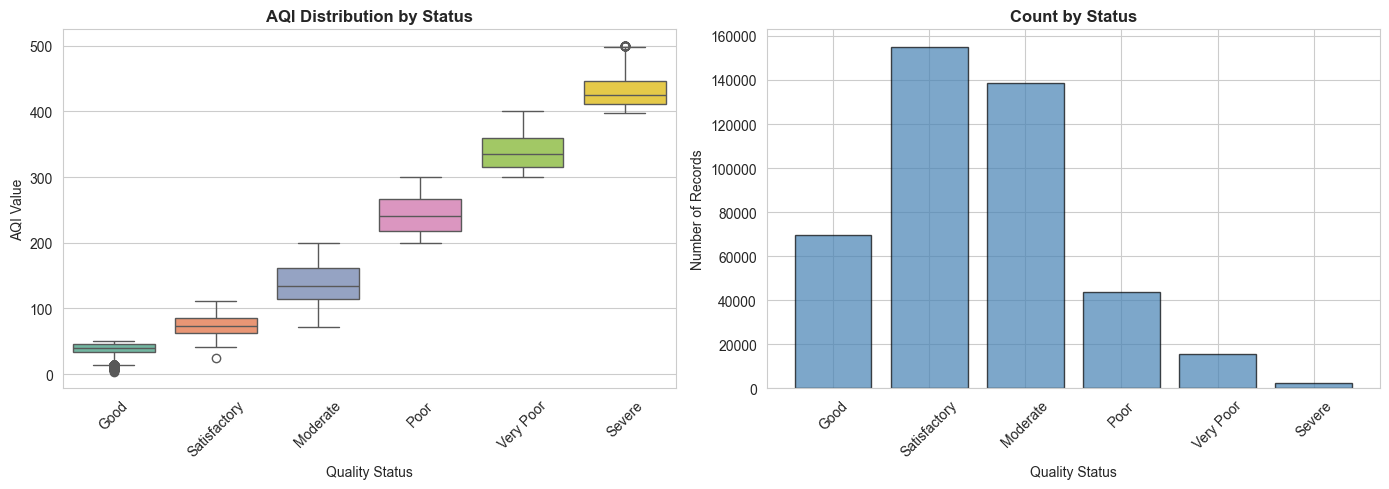

In [10]:
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
data_sorted = data.copy()
data_sorted['air_quality_status'] = pd.Categorical(data_sorted['air_quality_status'], categories=status_order, ordered=True)
data_sorted = data_sorted.sort_values('air_quality_status')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(x='air_quality_status', y='aqi_value', data=data_sorted, ax=axes[0], palette='Set2')
axes[0].set_title('AQI Distribution by Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality Status')
axes[0].set_ylabel('AQI Value')
axes[0].tick_params(axis='x', rotation=45)

# Count plot
status_counts = data['air_quality_status'].value_counts().reindex(status_order)
axes[1].bar(status_order, status_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title('Count by Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quality Status')
axes[1].set_ylabel('Number of Records')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Compare States

<< -- Top 10 States by Avg AQI -->>
                        mean  count         std
state                                          
delhi             215.759684   3666  102.893085
bihar             165.905256  30820   99.692995
himachal pradesh  160.133040   1135   71.701757
uttar pradesh     159.574449  44796  101.648709
haryana           151.491985  50654   89.042159
jharkhand         147.367081   1610   68.186898
rajasthan         130.720200  41501   68.007281
tripura           126.565670   1538   85.011101
odisha            123.680314  13995   68.834668
chandigarh        122.829909   2093   67.902421


<<--- Bottom 10 States by Avg AQI -->
                                  mean  count        std
state                                                   
chhattisgarh                 77.832926   6135  38.878905
tamil nadu                   69.848222  16590  40.349567
kerala                       67.518460  11999  30.077571
karnataka                    64.276258  37798  33.219549
andama

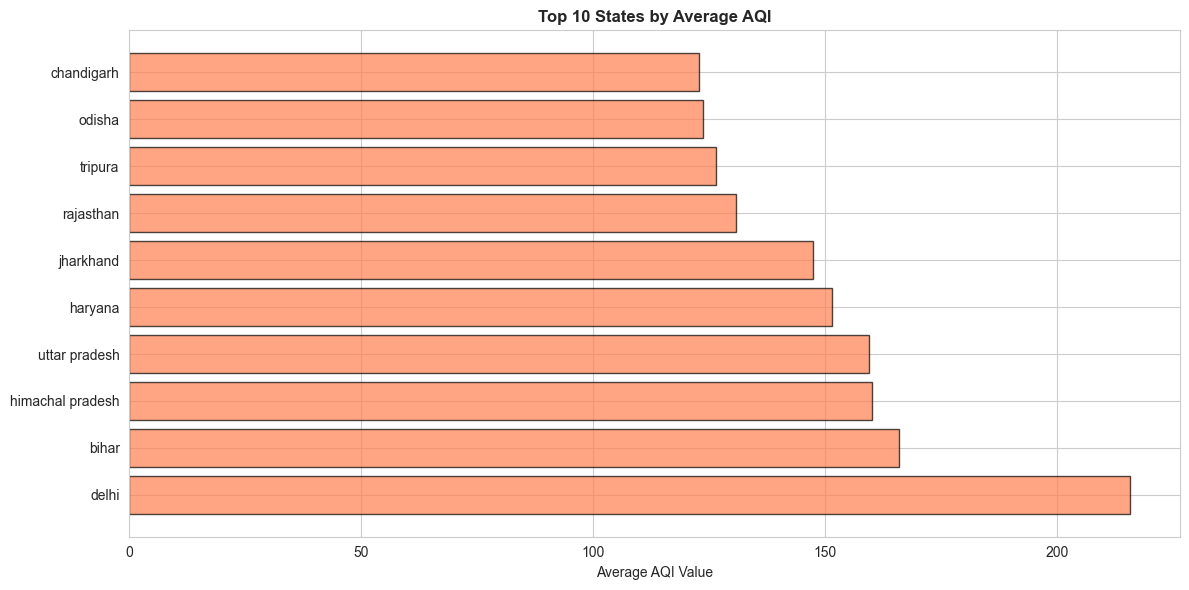

In [12]:
state_stats = data.groupby('state')['aqi_value'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

print("<< -- Top 10 States by Avg AQI -->>")
print(state_stats.head(10))
print("\n")
print("<<--- Bottom 10 States by Avg AQI -->")
print(state_stats.tail(10))

fig, ax = plt.subplots(figsize=(12, 6))
state_means = data.groupby('state')['aqi_value'].mean().sort_values(ascending=False).head(10)
ax.barh(state_means.index, state_means.values, color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Top 10 States by Average AQI', fontsize=12, fontweight='bold')
ax.set_xlabel('Average AQI Value')
plt.tight_layout()
plt.show()

## Hypothesis Testing: AQI in Good vs Severe Status

**Objective:** Check whether the average AQI is significantly different between `Good` and `Severe` air quality status.

**Test used:** Two-sample t-test

**Hypotheses:**
- H0: The mean AQI of `Good` and `Severe` status is the same
- H1: The mean AQI of `Good` and `Severe` status is different

In [10]:
from scipy import stats

good_aqi = data[data['air_quality_status'] == 'Good']['aqi_value']
severe_aqi = data[data['air_quality_status'] == 'Severe']['aqi_value']

t_stat, p_value = stats.ttest_ind(good_aqi, severe_aqi, equal_var=False)
alpha = 0.05

print("Hypothesis Test Results\n")

print(f"Good group size   : {len(good_aqi)}")
print(f"Severe group size : {len(severe_aqi)}")
print(f"Mean AQI (Good)   : {good_aqi.mean():.2f}")
print(f"Mean AQI (Severe) : {severe_aqi.mean():.2f}")
print(f"t-statistic       : {t_stat:.4f}")
print(f"p-value           : {p_value:.6f}")

print("\nDecision:")
if p_value < alpha:
    print("Reject H0: The AQI means are significantly different.")
else:
    print("Fail to reject H0: No significant difference in AQI means.")

Hypothesis Test Results

Good group size   : 69750
Severe group size : 2564
Mean AQI (Good)   : 38.53
Mean AQI (Severe) : 430.61
t-statistic       : -828.8783
p-value           : 0.000000

Decision:
Reject H0: The AQI means are significantly different.


## Summary

In [15]:
status_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
state_stats = data.groupby('state')['aqi_value'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60 + "\n")

print("1. Dataset Overview:")
print(f"   • Total records: {len(data):,}")
print(f"   • States covered: {data['state'].nunique()}")
print(f"   • AQI range: {data['aqi_value'].min():.0f} to {data['aqi_value'].max():.0f}")

print("\n2. Quality Status Distribution:")
for status in status_order:
    count = len(data[data['air_quality_status'] == status])
    pct = (count / len(data)) * 100
    print(f"   • {status}: {count:,} ({pct:.1f}%)")

print("\n3. Most Polluted States (Top 5):")
for i, (state, val) in enumerate(state_stats.head(5)['mean'].items(), 1):
    print(f"   {i}. {state}: {val:.1f}")

print("\n4. Cleanest States (Top 5):")
for i, (state, val) in enumerate(state_stats.tail(5)['mean'].items(), 1):
    print(f"   {i}. {state}: {val:.1f}")

print("\n5. Correlation with AQI:")
corr_with_aqi = data[['aqi_value', 'quality_level', 'month', 'year']].corr()['aqi_value'].drop('aqi_value')
for col, val in corr_with_aqi.items():
    print(f"   • {col}: {val:.3f}")

print("\n6. Hypothesis Test (Good vs Severe AQI):")
if p_value < alpha:
    print(f"   • Significant difference (p = {p_value:.6f} < {alpha})")
else:
    print(f"   • Not significant (p = {p_value:.6f} >= {alpha})")

print("\n" + "="*60)


KEY FINDINGS

1. Dataset Overview:
   • Total records: 425,138
   • States covered: 32
   • AQI range: 3 to 500

2. Quality Status Distribution:
   • Good: 69,750 (16.4%)
   • Satisfactory: 155,167 (36.5%)
   • Moderate: 138,489 (32.6%)
   • Poor: 43,784 (10.3%)
   • Very Poor: 15,384 (3.6%)
   • Severe: 2,564 (0.6%)

3. Most Polluted States (Top 5):
   1. delhi: 215.8
   2. bihar: 165.9
   3. himachal pradesh: 160.1
   4. uttar pradesh: 159.6
   5. haryana: 151.5

4. Cleanest States (Top 5):
   1. arunachal pradesh: 59.9
   2. puducherry: 56.0
   3. sikkim: 53.5
   4. meghalaya: 52.6
   5. mizoram: 45.1

5. Correlation with AQI:
   • quality_level: 0.935
   • month: 0.006
   • year: -0.163

6. Hypothesis Test (Good vs Severe AQI):
   • Significant difference (p = 0.000000 < 0.05)

